<a href="https://colab.research.google.com/github/kowshigadeviii-cmd/kowshiga/blob/main/Credit_Card_Fraud_Detection_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")


Libraries imported successfully!


In [13]:
from google.colab import files

uploaded = files.upload()

In [14]:
import zipfile

with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [16]:
import os

files = os.listdir("/content/dataset")
print("Files in dataset:")
print(files)

Files in dataset:
['creditcard.csv']


In [17]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset loaded successfully!
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
# Check dataset information
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

# Check fraud and normal transactions
print("\nTransaction Distribution:")
print(df["Class"].value_counts())

print("\n0 = Normal Transaction")
print("1 = Fraud Transaction")

Missing Values: 0
Duplicate Rows: 1081

Transaction Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

0 = Normal Transaction
1 = Fraud Transaction


In [19]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

# Check class distribution after cleaning
print("\nClass Distribution:")
print(df["Class"].value_counts())

Duplicates after cleaning: 0
Dataset shape after cleaning: (283726, 31)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64


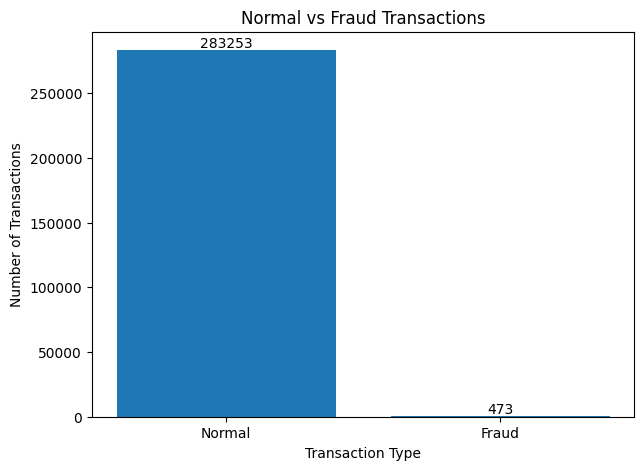

In [20]:
import matplotlib.pyplot as plt

counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(["Normal", "Fraud"], counts.values)

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale Time and Amount
scaler = StandardScaler()
X = X.copy()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

# Split dataset - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training fraud cases:", y_train.sum())
print("Testing fraud cases:", y_test.sum())

Training data: (226980, 30)
Testing data: (56746, 30)
Training fraud cases: 378
Testing fraud cases: 95


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create model
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model Training Completed!")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Model Training Completed!

Confusion Matrix:
[[55255  1396]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC-AUC Score: 0.9658137683266611


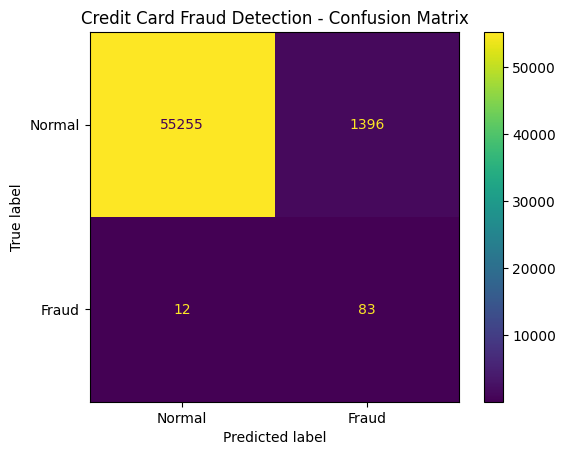

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Normal", "Fraud"],
    values_format="d"
)

plt.title("Credit Card Fraud Detection - Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import numpy as np

# Find threshold with best F1 score
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

# Predictions using optimized threshold
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("\nTuned Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nTuned Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Threshold: 0.9999995112016786
Best F1 Score: 0.813559321984168

Tuned Confusion Matrix:
[[56641    10]
 [   23    72]]

Tuned Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.76      0.81        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



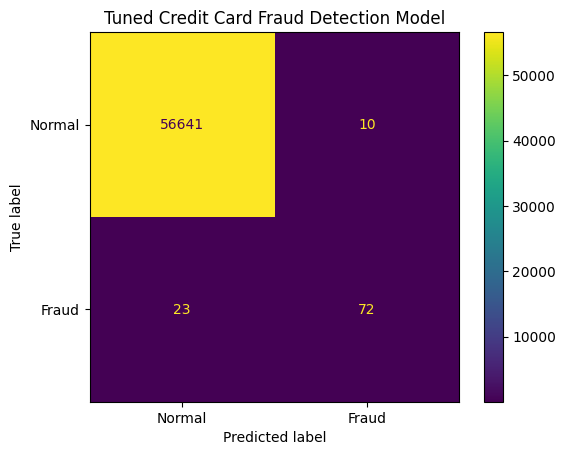

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=["Normal", "Fraud"],
    values_format="d"
)

plt.title("Tuned Credit Card Fraud Detection Model")
plt.show()

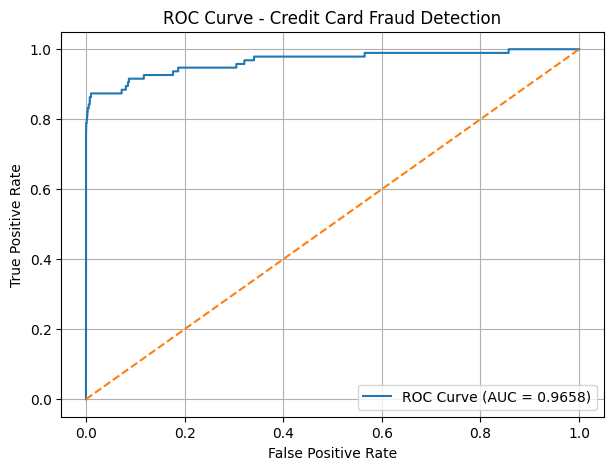

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.grid()

plt.show()

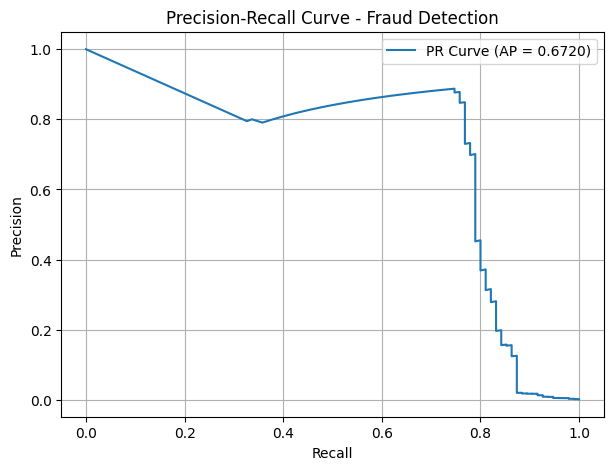

Average Precision Score: 0.6720110160925985


In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR Curve (AP = {ap_score:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fraud Detection")
plt.legend()
plt.grid()

plt.show()

print("Average Precision Score:", ap_score)

In [28]:
# Select one transaction from test data
sample_index = 0

sample = X_test.iloc[[sample_index]]
actual = y_test.iloc[sample_index]

# Predict fraud probability
fraud_probability = model.predict_proba(sample)[0][1]

# Apply tuned threshold
prediction = 1 if fraud_probability >= best_threshold else 0

print("===== CREDIT CARD FRAUD DETECTION =====")

print("\nFraud Probability:", fraud_probability)

if prediction == 1:
    print("Model Prediction: FRAUD TRANSACTION ⚠️")
else:
    print("Model Prediction: NORMAL TRANSACTION ✅")

print("Actual Transaction:", "FRAUD" if actual == 1 else "NORMAL")

===== CREDIT CARD FRAUD DETECTION =====

Fraud Probability: 0.021707470959882003
Model Prediction: NORMAL TRANSACTION ✅
Actual Transaction: NORMAL


In [29]:
# Select an actual fraud transaction from test data
fraud_positions = [i for i, value in enumerate(y_test.values) if value == 1]

# Find a fraud case that the tuned model correctly detects
for pos in fraud_positions:
    sample = X_test.iloc[[pos]]
    fraud_probability = model.predict_proba(sample)[0][1]

    if fraud_probability >= best_threshold:
        actual = y_test.iloc[pos]
        prediction = 1
        break

print("===== FRAUD TRANSACTION TEST =====")
print("Fraud Probability:", fraud_probability)
print("Model Prediction:", "FRAUD TRANSACTION ⚠️" if prediction == 1 else "NORMAL TRANSACTION")
print("Actual Transaction:", "FRAUD" if actual == 1 else "NORMAL")

===== FRAUD TRANSACTION TEST =====
Fraud Probability: 0.9999999998927764
Model Prediction: FRAUD TRANSACTION ⚠️
Actual Transaction: FRAUD


# Credit Card Fraud Detection Using Machine Learning

## Machine Learning Major Project

### Objective
To develop a machine learning model that identifies fraudulent credit card transactions and distinguishes them from legitimate transactions.

In [30]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Keep Class only for final evaluation
X_unsupervised = df.drop("Class", axis=1)

# Scale Time and Amount
scaler_unsupervised = StandardScaler()
X_unsupervised = X_unsupervised.copy()

X_unsupervised[["Time", "Amount"]] = scaler_unsupervised.fit_transform(
    X_unsupervised[["Time", "Amount"]]
)

# Create Isolation Forest model
iso_model = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# UNSUPERVISED TRAINING
# No Class/y labels are given to the model
iso_model.fit(X_unsupervised)

print("Isolation Forest training completed!")
print("Training Type: UNSUPERVISED LEARNING")

Isolation Forest training completed!
Training Type: UNSUPERVISED LEARNING


In [31]:
# Predict anomalies
iso_predictions = iso_model.predict(X_unsupervised)

# Isolation Forest output:
#  1 = Normal
# -1 = Anomaly

# Convert to 0 = Normal, 1 = Anomaly
anomaly_predictions = [1 if x == -1 else 0 for x in iso_predictions]

import pandas as pd

prediction_counts = pd.Series(anomaly_predictions).value_counts()

print("===== ISOLATION FOREST RESULTS =====")
print("Normal Transactions:", prediction_counts.get(0, 0))
print("Anomalous Transactions:", prediction_counts.get(1, 0))

===== ISOLATION FOREST RESULTS =====
Normal Transactions: 272972
Anomalous Transactions: 10754


In [32]:
from sklearn.metrics import confusion_matrix, classification_report

# Actual labels - ONLY for evaluation
y_actual = df["Class"].values

print("===== UNSUPERVISED MODEL EVALUATION =====")

print("\nConfusion Matrix:")
print(confusion_matrix(y_actual, anomaly_predictions))

print("\nClassification Report:")
print(classification_report(
    y_actual,
    anomaly_predictions,
    target_names=["Normal", "Fraud"]
))

===== UNSUPERVISED MODEL EVALUATION =====

Confusion Matrix:
[[272884  10369]
 [    88    385]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    283253
       Fraud       0.04      0.81      0.07       473

    accuracy                           0.96    283726
   macro avg       0.52      0.89      0.52    283726
weighted avg       1.00      0.96      0.98    283726



In [33]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

# Tuned Isolation Forest
iso_model_tuned = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

# Train WITHOUT Class labels
iso_model_tuned.fit(X_unsupervised)

# Predict
pred = iso_model_tuned.predict(X_unsupervised)

# -1 = anomaly -> 1
#  1 = normal  -> 0
tuned_anomaly_predictions = (pred == -1).astype(int)

print("===== TUNED ISOLATION FOREST =====")
print("Detected Anomalies:", tuned_anomaly_predictions.sum())

print("\nConfusion Matrix:")
print(confusion_matrix(y_actual, tuned_anomaly_predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_actual,
        tuned_anomaly_predictions,
        target_names=["Normal", "Fraud"]
    )
)

===== TUNED ISOLATION FOREST =====
Detected Anomalies: 568

Confusion Matrix:
[[282793    460]
 [   365    108]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    283253
       Fraud       0.19      0.23      0.21       473

    accuracy                           1.00    283726
   macro avg       0.59      0.61      0.60    283726
weighted avg       1.00      1.00      1.00    283726



In [34]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

iso_final = IsolationForest(
    n_estimators=200,
    contamination=0.005,
    random_state=42,
    n_jobs=-1
)

# Unsupervised training - no Class labels
iso_final.fit(X_unsupervised)

pred_final = iso_final.predict(X_unsupervised)
final_anomaly_predictions = (pred_final == -1).astype(int)

print("===== ISOLATION FOREST - 0.005 =====")
print("Detected Anomalies:", final_anomaly_predictions.sum())

print("\nConfusion Matrix:")
print(confusion_matrix(y_actual, final_anomaly_predictions))

print("\nClassification Report:")
print(classification_report(
    y_actual,
    final_anomaly_predictions,
    target_names=["Normal", "Fraud"]
))

===== ISOLATION FOREST - 0.005 =====
Detected Anomalies: 1419

Confusion Matrix:
[[282019   1234]
 [   288    185]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    283253
       Fraud       0.13      0.39      0.20       473

    accuracy                           0.99    283726
   macro avg       0.56      0.69      0.60    283726
weighted avg       1.00      0.99      1.00    283726



In [36]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

# Isolation Forest with 1% contamination
iso_model_001 = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

# UNSUPERVISED TRAINING - Class label is NOT used
iso_model_001.fit(X_unsupervised)

# Predict anomalies
pred_001 = iso_model_001.predict(X_unsupervised)

# Isolation Forest:
#  1 = Normal
# -1 = Anomaly
predictions_001 = (pred_001 == -1).astype(int)

print("===== ISOLATION FOREST - 0.01 =====")
print("Detected Anomalies:", predictions_001.sum())

# Actual Class is used ONLY for evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_actual, predictions_001))

print("\nClassification Report:")
print(
    classification_report(
        y_actual,
        predictions_001,
        target_names=["Normal", "Fraud"]
    )
)

===== ISOLATION FOREST - 0.01 =====
Detected Anomalies: 2838

Confusion Matrix:
[[280677   2576]
 [   211    262]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    283253
       Fraud       0.09      0.55      0.16       473

    accuracy                           0.99    283726
   macro avg       0.55      0.77      0.58    283726
weighted avg       1.00      0.99      0.99    283726



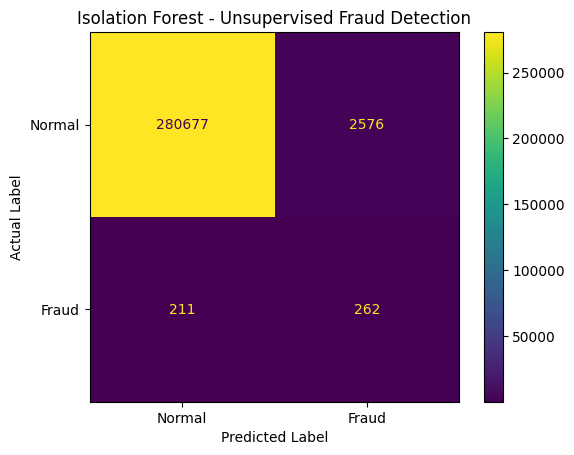

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_actual,
    predictions_001,
    display_labels=["Normal", "Fraud"],
    values_format="d"
)

plt.title("Isolation Forest - Unsupervised Fraud Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

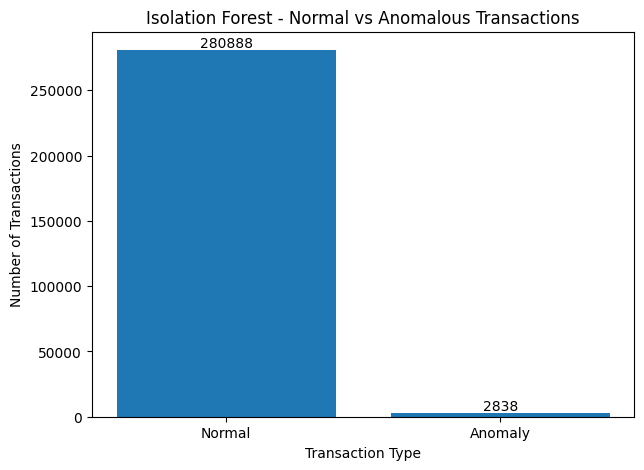

Normal Transactions: 280888
Anomalous Transactions: 2838


In [38]:
import matplotlib.pyplot as plt

normal_count = (predictions_001 == 0).sum()
anomaly_count = (predictions_001 == 1).sum()

plt.figure(figsize=(7, 5))
plt.bar(["Normal", "Anomaly"], [normal_count, anomaly_count])

plt.title("Isolation Forest - Normal vs Anomalous Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.text(0, normal_count, str(normal_count), ha="center", va="bottom")
plt.text(1, anomaly_count, str(anomaly_count), ha="center", va="bottom")

plt.show()

print("Normal Transactions:", normal_count)
print("Anomalous Transactions:", anomaly_count)

In [39]:
import joblib

joblib.dump(iso_model, "credit_card_anomaly_isolation_forest.pkl")

print("Model saved successfully!")
print("Project: Credit Card Fraud/Anomaly Detection")
print("Algorithm: Isolation Forest")
print("Learning Type: Unsupervised Learning")
print("PROJECT COMPLETED SUCCESSFULLY!")

Model saved successfully!
Project: Credit Card Fraud/Anomaly Detection
Algorithm: Isolation Forest
Learning Type: Unsupervised Learning
PROJECT COMPLETED SUCCESSFULLY!


PROJECT SUMMARY

Title: Credit Card Fraud / Anomaly Detection

Learning Type: Unsupervised Machine Learning

Algorithm: Isolation Forest

Objective:
To identify unusual or anomalous credit card transactions without using fraud labels during model training.

The Isolation Forest model analyzes transaction patterns and separates normal transactions from anomalous transactions.

Result:
The model successfully detected anomalous transactions from the credit card dataset.

Conclusion:
This project demonstrates how unsupervised machine learning can be used for credit card anomaly detection.

PROJECT COMPLETED SUCCESSFULLY